In this notebook:

1. Confusion matrix for the training set
2. Showing the effect of tuning hyperparameters
3. Final dashboard for evaluation of all 3 models

*note: The quality in this notebook might not be as high as the previous ones as the explanations and presentation are not fully completed yet. However, the results and its learnings are final.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utilities_notebook import load_ml_data, sigmoid, compute_cost, compute_gradient, run_gradient_descent, predict, zscore_normalize_features, apply_zscore_normalization, evaluate_classification_performance, evaluate_classification_performance_2

Loaded data from: linear
X_train: (567, 6), y_train: (567, 1)
X_test : (144, 6), y_test : (144, 1)

Iteration    0: Cost  0.68841
Iteration 1000: Cost  0.64151
Iteration 2000: Cost  0.64149
Iteration 3000: Cost  0.64149
Iteration 4000: Cost  0.64149
Iteration 5000: Cost  0.64149
Iteration 6000: Cost  0.64149
Iteration 7000: Cost  0.64149
Iteration 8000: Cost  0.64149
Iteration 9000: Cost  0.64149
Iteration 9999: Cost  0.64149


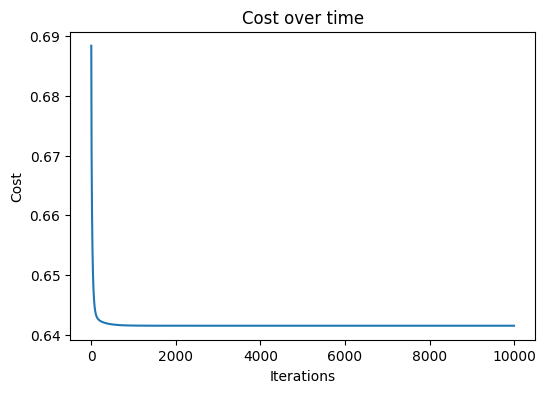

In [43]:
# Load and train linear logistic regression model

X_train, X_test, y_train, y_test = load_ml_data("../data", "linear")
features = ['volume', 'pct_change_1d', 'rsi', 'adx']
X_train_norm, X_train_mu, X_train_sigma = zscore_normalize_features(X_train, columns=features)
w_in = np.zeros(X_train_norm.shape[1])
b_in = 0

w, b = run_gradient_descent(X_train_norm.values, y_train.values.reshape(-1), w_in, b_in, compute_cost,
                            compute_gradient, alpha=0.1, num_iters=10000, lambda_=0)
f_wb, p = predict(X_train_norm, w, b)

## 1 Confusion Matrix

- Evaluating the linear logistic regression model
- Evaluating the polynomial logistic regression model

The models are first evaluated on the training set.

#### Evaluating the linear logistic regression model

In [44]:
def get_confusion_matrix(y_test, true_col='signal', pred_col='pred'):
    """
    Calculates the TN, FP, FN, TP from a (m, 2) DataFrame where the first column
    are the true labels, and the second column are the predicted labels, and m is
    the number of samples
    """
    positive = y_test[y_test[true_col] == 1] # filter dataframe by true positive labels
    negative = y_test[y_test[true_col] == 0] # filter dataframe by true negative labels

    # True Negatives: # y_true=0, y_pred=0
    TN = len(negative[negative[pred_col] == 0])
    # False Positives: # y_true=0, y_pred=1
    FP = len(negative[negative[pred_col] == 1])
    # False Negatives: # y_true=1, y_pred=0
    FN = len(positive[positive[pred_col] == 0])
    # True Positives: # y_true=1, y_pred=1
    TP = len(positive[positive[pred_col] == 1])

    print(f"Confusion matrix manual implementation         - TN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}, Total Count = {TN+FP+FN+TP}")

    return TN, FP, FN, TP

In [45]:
def plot_confusion_matrix(y_true, y_pred, confusion_matrix_plot_f):
    """
    Args:
        y_pred (ndarray or Series (m,)) : predicted labels from a classifier
    """
    confusion_matrix_plot_f(y_true, y_pred)
    plt.show()

In the cell below:
- Show that our manual implementation of the confusion matrix is equivalent to Scikit-learn's
- Obtain confusion matrix metrics for our linear logistic regression model
- Plot the confusion matrix using Scikit-learn's ConfusionMatrixDisplay class

Confusion matrix manual implementation         - TN: 283, FP: 52, FN: 165, TP: 67, Total Count = 567
Confusion matrix scikit-learn's implementation - TN: 283, FP: 52, FN: 165, TP: 67, Total Count = 567

TPR: 0.289, TNR: 0.845
Precision: 0.563, NPV: 0.632


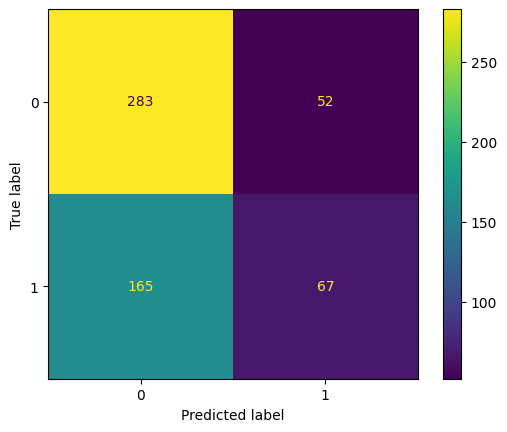

In [46]:
y_train['pred'] = p.reshape((-1, 1))

TN, FP, FN, TP = get_confusion_matrix(y_train)

# check confusion matrix metrics with scikit-learn's confusion matrix implementation
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_train['signal'], p).ravel().tolist() 

print(f"Confusion matrix scikit-learn's implementation - TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}, Total Count = {tn+fp+fn+tp}\n")

# detailed classification metrics
TPR = TP / (TP+FN) # True Positive Rate (Sensitivity/Recall) = TP / (TP+FN)
TNR = TN / (TN+FP) # True Negative Rate (Specificity) = TN / (TN+FP)
print(f"TPR: {TPR:0.3f}, TNR: {TNR:0.3f}")

NPV = TN / (TN+FN) # Negative Predictive Value
precision = TP / (TP+FP) # Precision: accuracy of the positive predictions
print(f"Precision: {precision:0.3f}, NPV: {NPV:0.3f}")

# display confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

plot_confusion_matrix(y_train['signal'], p, ConfusionMatrixDisplay.from_predictions)

The linear logistic regression model shows that with a probability threshold of 0.5 for predicting the positive class, it leans on the conservative side.

**The Precision** (0.56) is better than a random coin flip (0.50), showing that its positive predictions are correct 56% of the time. For our application, it correctly predicts more than half of the time that the next day close price will be higher than the previous day close price.

**The Recall (or True Positive Rate)** however is very low, showing its conservatism in predicting an increase for the next day close price. The model will tend to predict that the next day close will decrease or have no change. A value of 0.29 indicates that even though the next day close price will increase, the model predicts it will increase only 29% of the time.

**The True Negative Rate (TNR)** of 0.85 is very high, showing that it predicts negative samples with an 85% accuracy. Or in our application, it correctly predicts 85% of the time that the next day close price will indeed be lower or have no change from the previous close price.

In [47]:
def plot_confusion_matrix_at_thresholds(y_true, y_score, confusion_matrix_at_thresholds):
    """
    Plots the TN, FP, FN, TP of a classifier at different thresholds

    Args:
        y_true (ndarray or Series (m,))             : true labels with m samples
        y_score (ndarray or Series (m,))            : threshold probabilities of m samples being the positive class
        confusion_matrix_at_thresholds (function)   : Scikit-learn function that computes the TNs, FPs, FNs, TPs,
                                                      and threshold values for binary classification
    """
    tns, fps, fns, tps, threshold = confusion_matrix_at_thresholds(y_true, y_score)

    # Plot TNs, FPs, FNs and TPs vs Thresholds
    plt.figure(figsize=(10, 6))

    plt.plot(threshold, tns, label="True Negatives (TNs)")
    plt.plot(threshold, fps, label="False Positives (FPs)")
    plt.plot(threshold, fns, label="False Negatives (FNs)")
    plt.plot(threshold, tps, label="True Positives (TPs)")
    plt.xlabel("Thresholds")
    plt.ylabel("Count")
    plt.title("TNs, FPs, FNs and TPs vs Thresholds")
    plt.legend()
    plt.grid()

    plt.show()

In [48]:
def plot_precision_call_vs_threshold(y_true, y_score, precision_recall_curve_f):

    precisions, recalls, thresholds = precision_recall_curve_f(y_true, y_score)

    plt.plot(thresholds, precisions[:-1], 'b--', label='precision')
    plt.plot(thresholds, recalls[:-1], 'g--', label='recall')
    plt.title('Precision-Recall Curve')
    plt.xlabel('Threshold')
    plt.ylabel('Values (between 0 and 1)')
    plt.legend()
    plt.show()

In [49]:
def plot_roc_curve(y_true, y_score, roc_curve_f, roc_auc_score_f):
    fpr, tpr, thresholds = roc_curve_f(y_true, y_score)

    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC Curve (AUC Score: {roc_auc_score_f(y_true, y_score):0.3f})')
    plt.legend()
    plt.show()
    

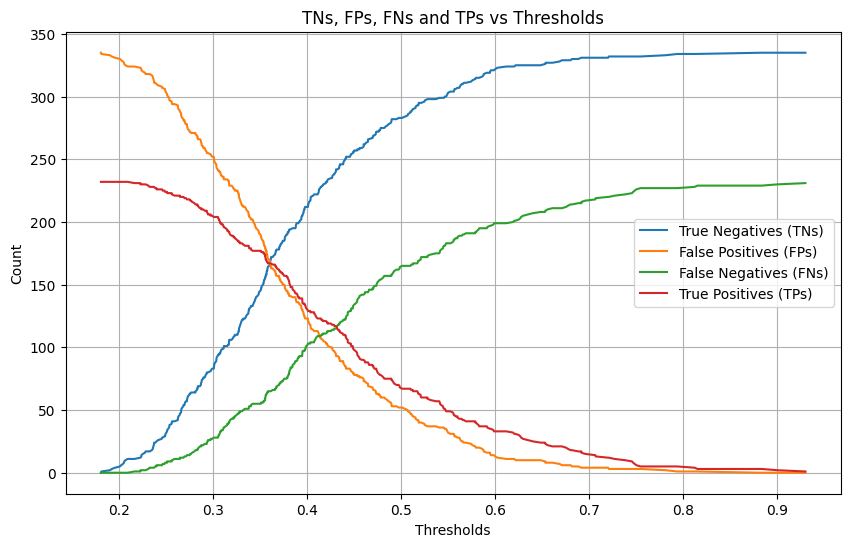

In [50]:
from sklearn.metrics import confusion_matrix_at_thresholds

plot_confusion_matrix_at_thresholds(y_train['signal'], f_wb, confusion_matrix_at_thresholds)

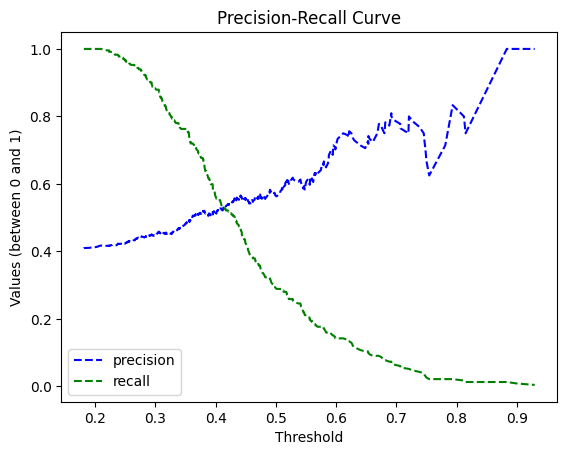

In [51]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

plot_precision_call_vs_threshold(y_train['signal'], f_wb, precision_recall_curve)

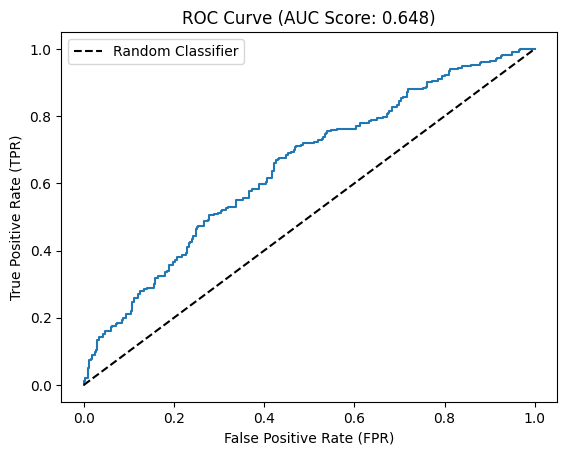

In [52]:
from sklearn.metrics import roc_curve, roc_auc_score

plot_roc_curve(y_train['signal'], f_wb, roc_curve, roc_auc_score)


___
#### Evaluating the polynomial logistic regression model

The same process is repeated for the polynomial logistic regression model.

Loaded data from: poly
X_poly_train: (562, 27), y_poly_train: (562, 1)
X_poly_test : (144, 27), y_poly_test : (144, 1)

Iteration    0: Cost  0.68478
Iteration 5000: Cost  0.63083
Iteration 10000: Cost  0.63030
Iteration 15000: Cost  0.63003
Iteration 20000: Cost  0.62985
Iteration 25000: Cost  0.62973
Iteration 30000: Cost  0.62964
Iteration 35000: Cost  0.62957
Iteration 40000: Cost  0.62951
Iteration 45000: Cost  0.62947
Iteration 49999: Cost  0.62943


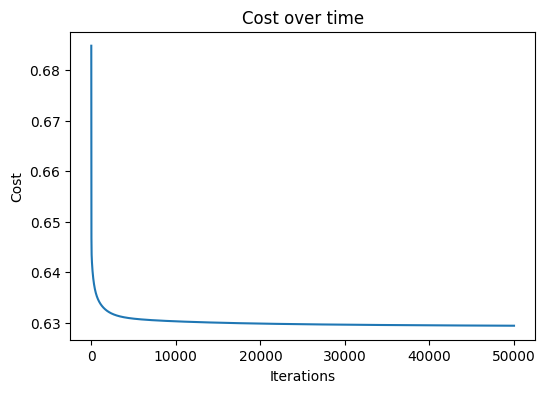

In [53]:
X_poly_train, X_poly_test, y_poly_train, y_poly_test = load_ml_data("../data", "poly")

exclude = ['corr', 'volatility', 'corr^2', 'pct_change_1d*volatility']
cols_to_scale = [c for c in X_poly_train.columns if c not in exclude]
X_poly_train_norm, X_poly_train_mu, X_poly_train_sigma = zscore_normalize_features(X_poly_train, columns=cols_to_scale)

w2_in = np.zeros(X_poly_train_norm.shape[1])
b2_in = 0
w2, b2 = run_gradient_descent(X_poly_train_norm.values, y_poly_train['signal'].values, w2_in, b2_in, compute_cost,
                                            compute_gradient, alpha=0.1, num_iters=50000, lambda_=0)

f_wb3, p3 = predict(X_poly_train_norm, w2, b2)

Confusion matrix manual implementation         - TN: 281, FP: 53, FN: 151, TP: 77, Total Count = 562


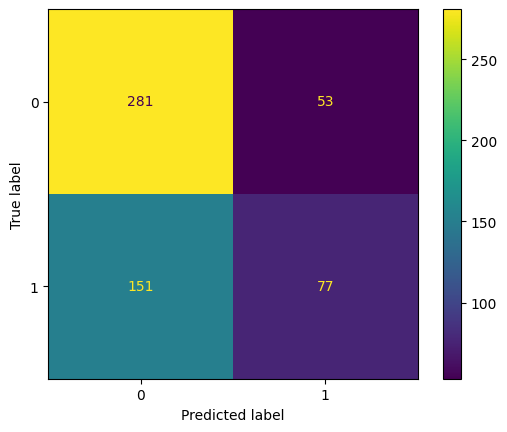

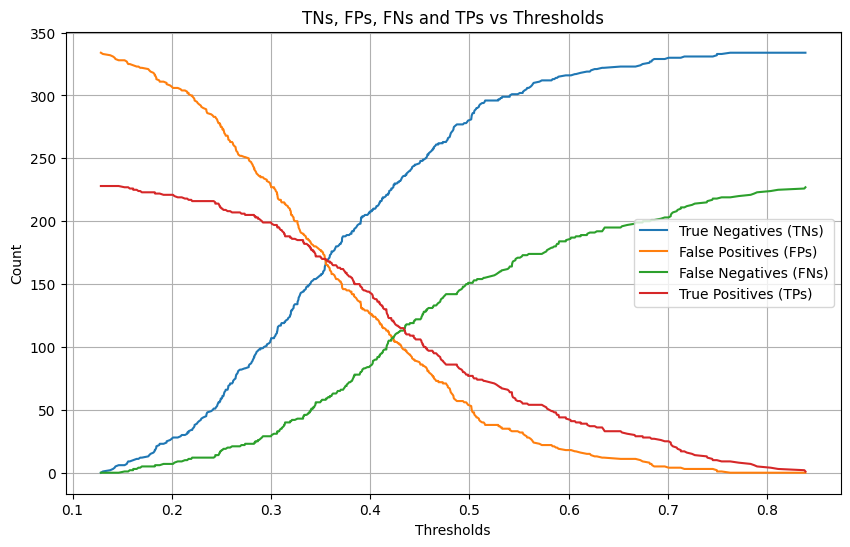

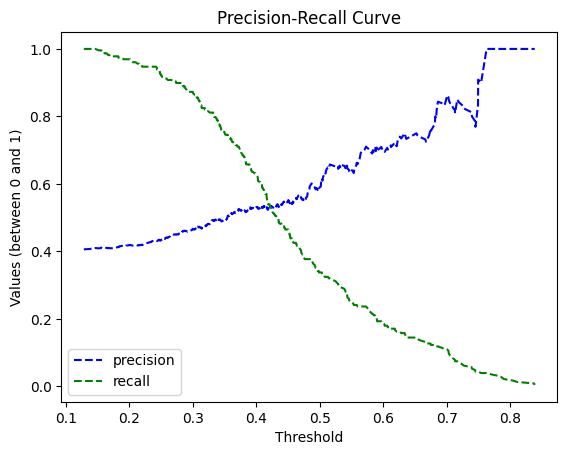

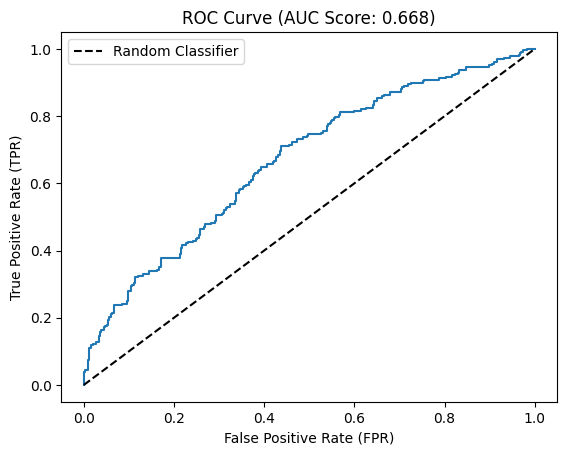

In [54]:
y_poly_train['pred'] = p3.reshape((-1, 1))
y_prob = f_wb3

get_confusion_matrix(y_poly_train)
plot_confusion_matrix(y_poly_train['signal'], y_poly_train['pred'], ConfusionMatrixDisplay.from_predictions)

plot_confusion_matrix_at_thresholds(y_poly_train['signal'], y_prob, confusion_matrix_at_thresholds)
plot_precision_call_vs_threshold(y_poly_train['signal'], y_prob, precision_recall_curve)
plot_roc_curve(y_poly_train['signal'], y_prob, roc_curve, roc_auc_score)

The polynomial logistic regression model seems to be a better classifier with an AUC (Area under Curve) score for the ROC curve of 0.668 compared with the linear logistic regression model's AUC score of 0.648.

But this is expected as the polynomial model should be expected to fit more tightly to the training set.

What actually matters is the final AUC score on the test set which tests generalizability of the model on unseen data.
___

## 2 Effect of Tuning Hyperparameters

- Linear logistic regression
- Polynomial logistic regression
- Regularized polynomial logistic regression

Two hyperparameters are tuned here:
1. The decision threshold for binary classification of $f_{w,b}(\mathbf{x})$
2. Regularization parameter for polynomial logistic regression

The decision threshold is tuned from our investigations of the confusion matrix above before evaluating the classification models on the test set. This is showed with the linear logistic regression model and the polynomial logistic regression model.

The effect of regularization is shown by tuning the regularization parameter of the existing polynomial logistic regression model.

#### Linear Logistic Regression

In [55]:
# apply z-score normalization with mean and standard deviation values calculated from the train set
X_test_norm = apply_zscore_normalization(X_test, X_train_mu, X_train_sigma, columns=features) 
f_wb2, p2 = predict(X_test_norm, w, b, p=0.4)

Confusion matrix manual implementation         - TN: 32, FP: 57, FN: 20, TP: 35, Total Count = 144
TPR: 0.636, TNR: 0.360
Precision: 0.380, NPV: 0.615


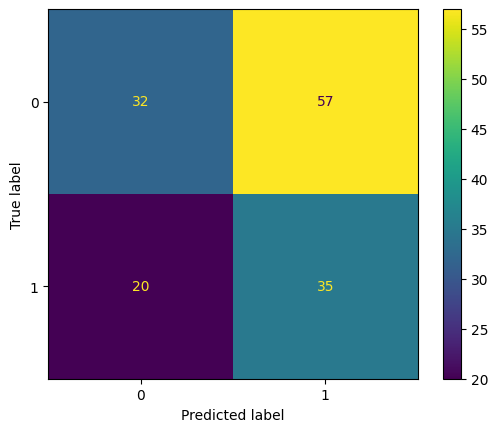

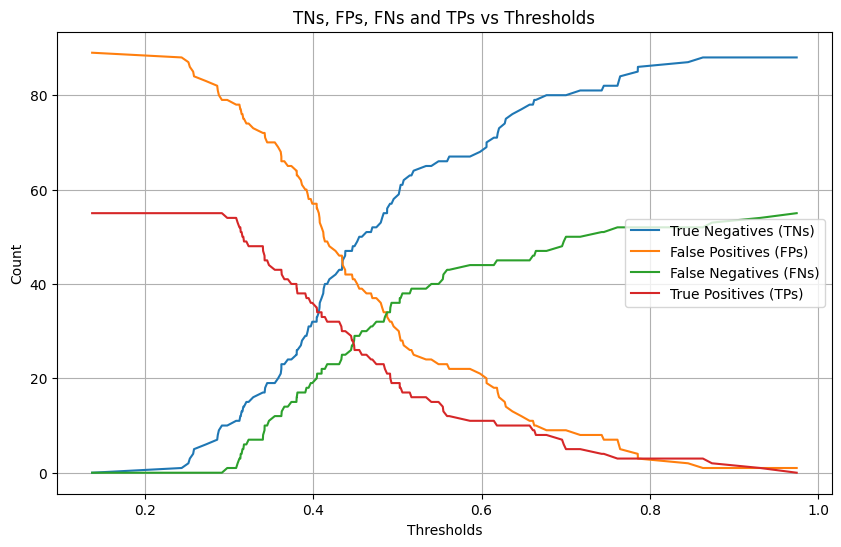

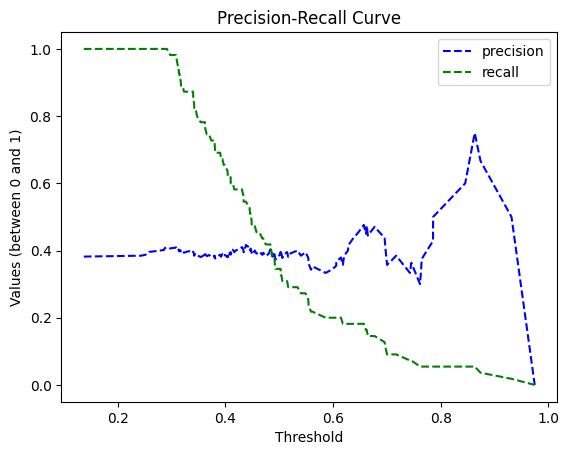

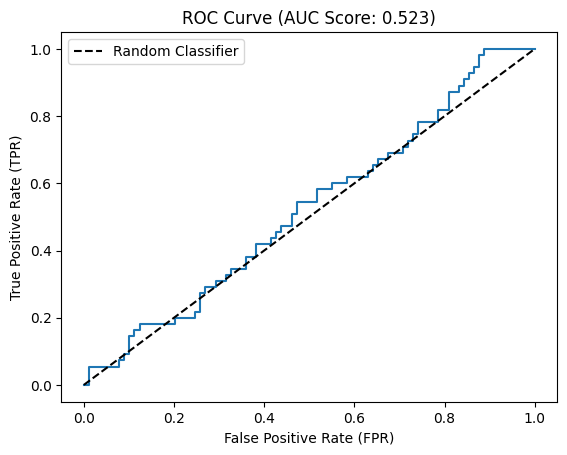

In [56]:
y_test['pred'] = p2.reshape((-1, 1))
y_true = y_test['signal']
y_prob = f_wb2

TN, FP, FN, TP = get_confusion_matrix(y_test)

# detailed classification metrics
TPR = TP / (TP+FN) # True Positive Rate (Sensitivity/Recall) = TP / (TP+FN)
TNR = TN / (TN+FP) # True Negative Rate (Specificity) = TN / (TN+FP)
print(f"TPR: {TPR:0.3f}, TNR: {TNR:0.3f}")

NPV = TN / (TN+FN) # Negative Predictive Value
precision = TP / (TP+FP) # Precision: accuracy of the positive predictions
print(f"Precision: {precision:0.3f}, NPV: {NPV:0.3f}")

plot_confusion_matrix(y_true, y_test['pred'], ConfusionMatrixDisplay.from_predictions)

plot_confusion_matrix_at_thresholds(y_true, y_prob, confusion_matrix_at_thresholds)
plot_precision_call_vs_threshold(y_true, y_prob, precision_recall_curve)
plot_roc_curve(y_true, y_prob, roc_curve, roc_auc_score)

#### Polynomial Logistic Regression

The same process is repeated for the polynomial logistic regression model with a slightly different decision threshold of 0.42.

In [57]:
X_poly_test_norm = apply_zscore_normalization(X_poly_test, X_poly_train_mu, X_poly_train_sigma, cols_to_scale)
f_wb4, p4 = predict(X_poly_test_norm, w2, b2, p=0.42)

print(f"Test Accuracy: {np.mean(p4 == y_poly_test['signal'].values) * 100:0.2f}%")

Test Accuracy: 51.39%


Test accuracy increased slightly from 50.69% to 51.39% but this is trivial.

Confusion matrix manual implementation         - TN: 41, FP: 48, FN: 22, TP: 33, Total Count = 144
TPR: 0.600, TNR: 0.461
Precision: 0.407, NPV: 0.651


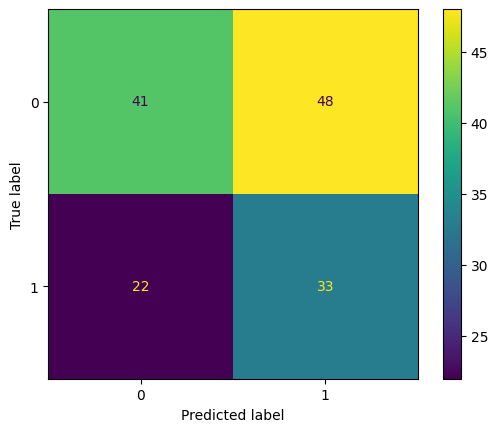

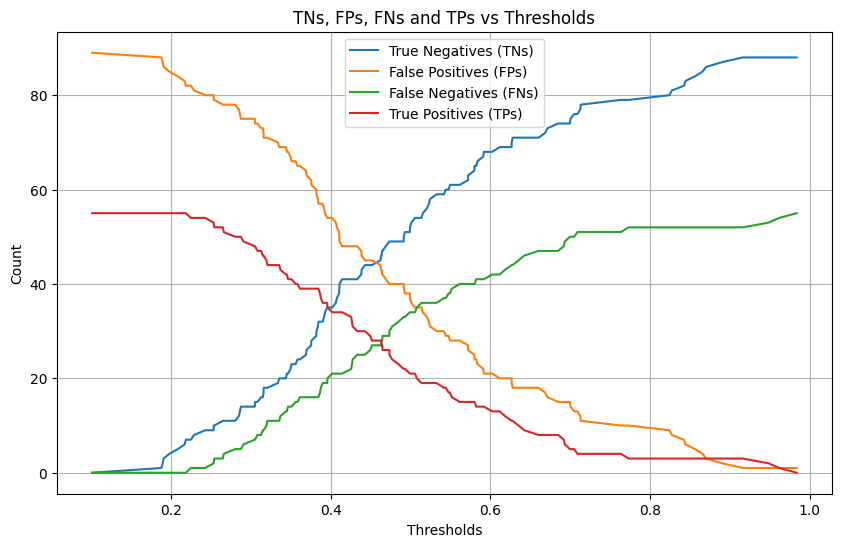

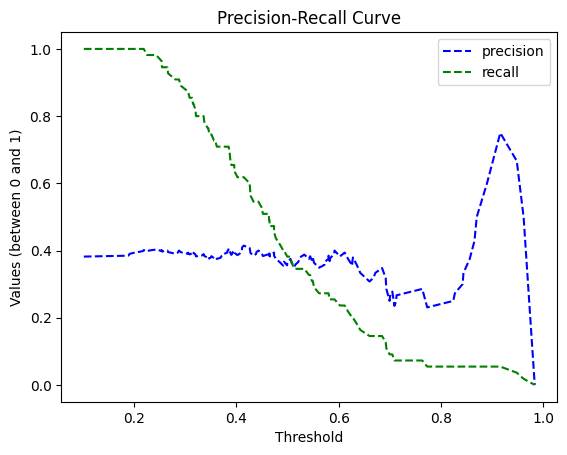

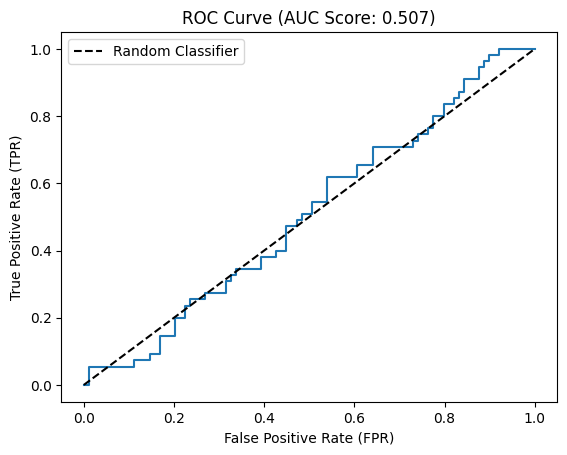

In [58]:
y_poly_test['pred'] = p4.reshape((-1, 1))
y_true = y_poly_test['signal']
y_prob = f_wb4

TN, FP, FN, TP = get_confusion_matrix(y_poly_test)

# detailed classification metrics
TPR = TP / (TP+FN) # True Positive Rate (Sensitivity/Recall) = TP / (TP+FN)
TNR = TN / (TN+FP) # True Negative Rate (Specificity) = TN / (TN+FP)
print(f"TPR: {TPR:0.3f}, TNR: {TNR:0.3f}")

NPV = TN / (TN+FN) # Negative Predictive Value
precision = TP / (TP+FP) # Precision: accuracy of the positive predictions
print(f"Precision: {precision:0.3f}, NPV: {NPV:0.3f}")

plot_confusion_matrix(y_true, y_poly_test['pred'], ConfusionMatrixDisplay.from_predictions)

plot_confusion_matrix_at_thresholds(y_true, y_prob, confusion_matrix_at_thresholds)
plot_precision_call_vs_threshold(y_true, y_prob, precision_recall_curve)
plot_roc_curve(y_true, y_prob, roc_curve, roc_auc_score)

As seen above, both AUC scores for the linear logistic regression model and the polynomial logistic regression model have dropped significantly with an AUC score of 0.523 for the former and an AUC score of 0.507 for the latter.

For other applications such as medical diagnosis, these classifiers would be considered terrible and not usable in any form. However, for financial applications such as predicting stock price, a classifier that is only slightly better than a coin flip is still bad but it is not uncommon, as classifiers with high AUC scores quickly get discovered and its edge slowly dissipates as more market participants use the same model.
___

#### Regularized Polynomial Logistic Regression

In the two models above, the simpler linear model edges out as a slightly better classifier than polynomial logistic regression.

However, polynomial features causes the model to have a tighter fit on the training data which might lead to overfitting and thus poorer generalization to the test data.

Applying regularization to the polynomial model penalizes the large coefficients of the model and thus reduces the effect of overfitting. Let us investigate if this produces a better classifier overall.

The regularization parameter is set to 20.

Iteration    0: Cost  0.68480
Iteration 5000: Cost  0.64204
Iteration 10000: Cost  0.64204
Iteration 15000: Cost  0.64204
Iteration 20000: Cost  0.64204
Iteration 25000: Cost  0.64204
Iteration 30000: Cost  0.64204
Iteration 35000: Cost  0.64204
Iteration 40000: Cost  0.64204
Iteration 45000: Cost  0.64204
Iteration 49999: Cost  0.64204


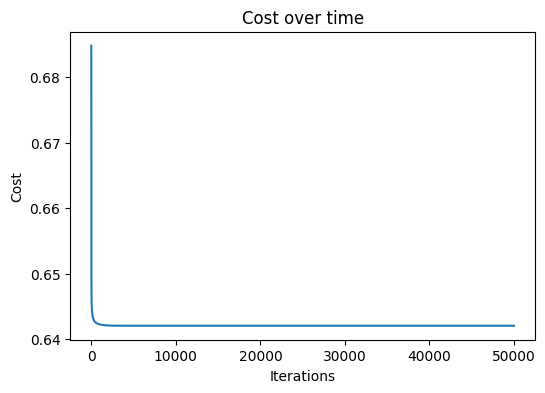

Train accuracy: 62.99%
Test Accuracy: 52.78%


In [59]:
w3_in = np.zeros(X_poly_train_norm.shape[1])
b3_in = 0
w3, b3 = run_gradient_descent(X_poly_train_norm.values, y_poly_train['signal'].values, w3_in, b3_in, compute_cost,
                                            compute_gradient, alpha=0.1, num_iters=50000, lambda_=20)

f_wb5, p5 = predict(X_poly_train_norm, w3, b3, p=0.46) # computed just to see train accuracy of regularized polynomial logistic regression
print(f"Train accuracy: {np.mean(p5==y_poly_train['signal'].values) * 100:0.2f}%")

f_wb6, p6 = predict(X_poly_test_norm, w3, b3, p=0.46)
print(f"Test Accuracy: {np.mean(p6 == y_poly_test['signal'].values) * 100:0.2f}%")

Test Accuracy has a slight increase from the unregularized version from 52.08% to 52.78%.

Confusion matrix manual implementation         - TN: 53, FP: 36, FN: 32, TP: 23, Total Count = 144
TPR: 0.418, TNR: 0.596
Precision: 0.390, NPV: 0.624


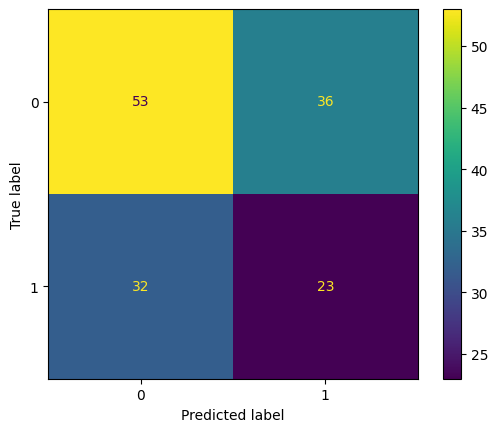

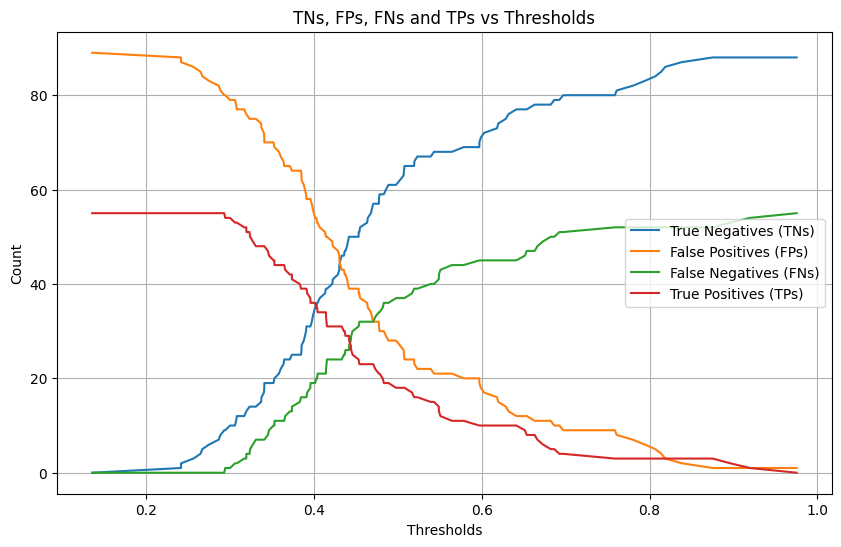

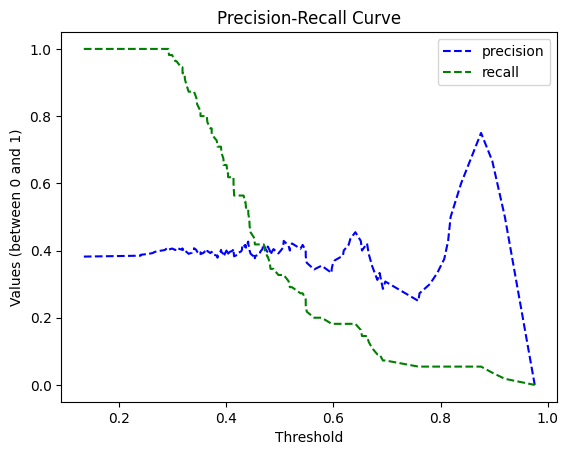

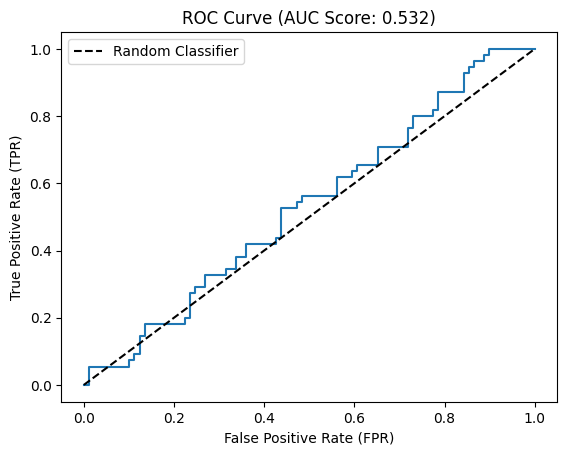

In [60]:
y_poly_test['pred'] = p6.reshape((-1, 1))
y_true = y_poly_test['signal']
y_prob = f_wb6

TN, FP, FN, TP = get_confusion_matrix(y_poly_test)

# detailed classification metrics
TPR = TP / (TP+FN) # True Positive Rate (Sensitivity/Recall) = TP / (TP+FN)
TNR = TN / (TN+FP) # True Negative Rate (Specificity) = TN / (TN+FP)
print(f"TPR: {TPR:0.3f}, TNR: {TNR:0.3f}")

NPV = TN / (TN+FN) # Negative Predictive Value
precision = TP / (TP+FP) # Precision: accuracy of the positive predictions
print(f"Precision: {precision:0.3f}, NPV: {NPV:0.3f}")

plot_confusion_matrix(y_true, y_poly_test['pred'], ConfusionMatrixDisplay.from_predictions)

plot_confusion_matrix_at_thresholds(y_true, y_prob, confusion_matrix_at_thresholds)
plot_precision_call_vs_threshold(y_true, y_prob, precision_recall_curve)
plot_roc_curve(y_true, y_prob, roc_curve, roc_auc_score)

As expected, the regularized polynomial regression model performs slightly better now compared with its linear counterpart with an AUC score of 0.532.

## 3 Final Dashboard of Classification Models

- Linear Logistic Regression
- Polynomial Logistic Regression
- Regularized Polynomial Logistic Regression

Final verdict: Regularized Logistic Regression was chosen as the final model for deployment with ROC of 0.532

Confusion matrix manual implementation         - TN: 32, FP: 57, FN: 20, TP: 35, Total Count = 144
TPR: 0.636, TNR: 0.360
Precision: 0.380, NPV: 0.615


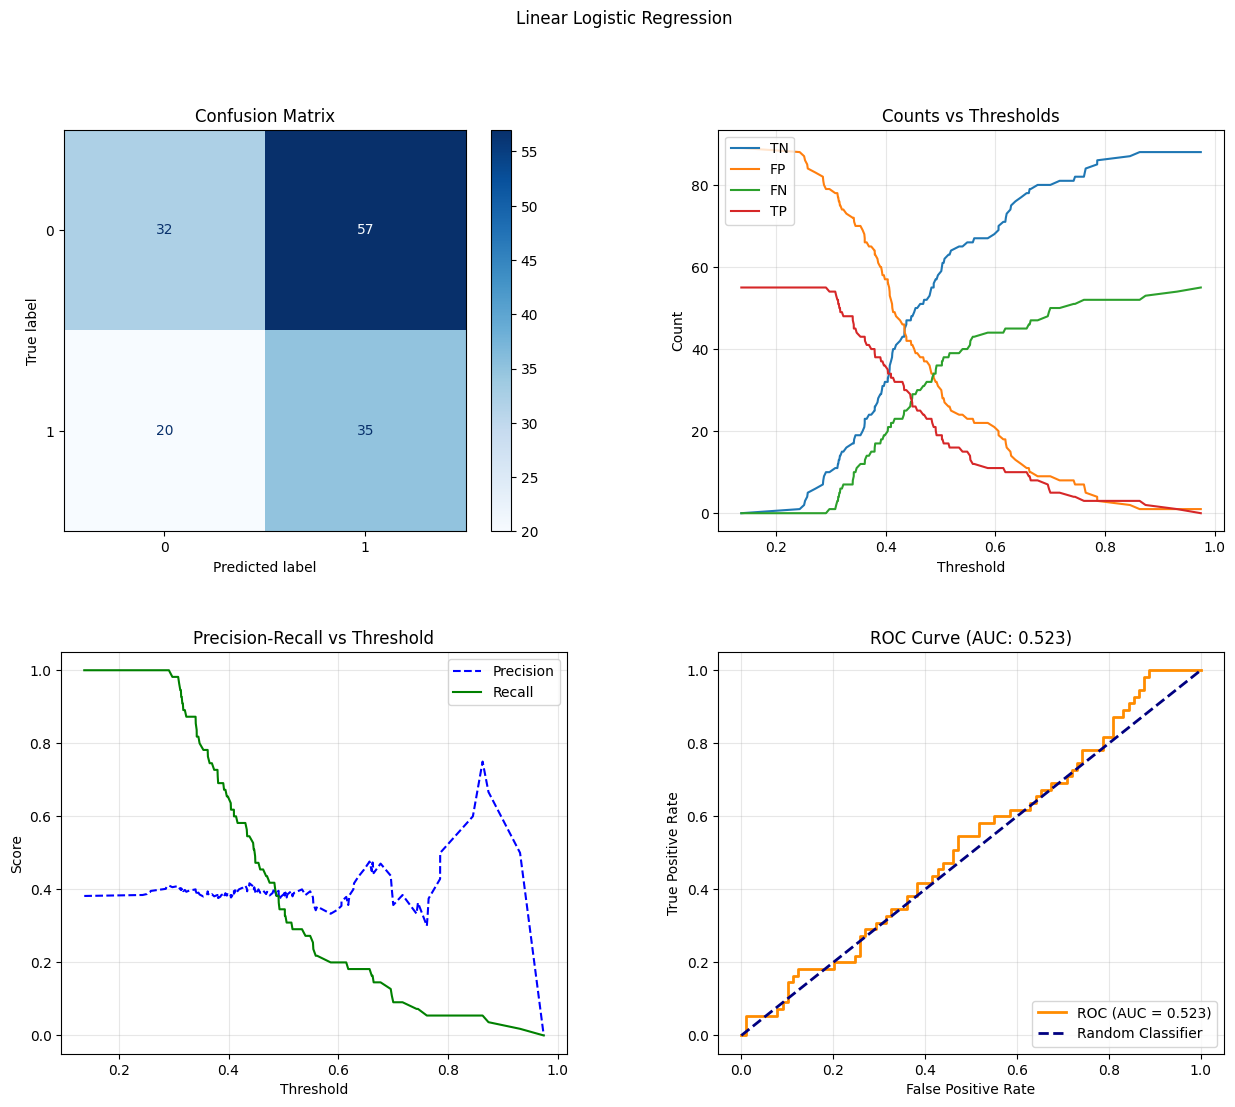

In [61]:
evaluate_classification_performance(y_test, p2, f_wb2,
                                    confusion_matrix_at_thresholds,
                                    precision_recall_curve,
                                    roc_curve,
                                    roc_auc_score,
                                    'Linear Logistic Regression')

Confusion matrix manual implementation         - TN: 41, FP: 48, FN: 22, TP: 33, Total Count = 144


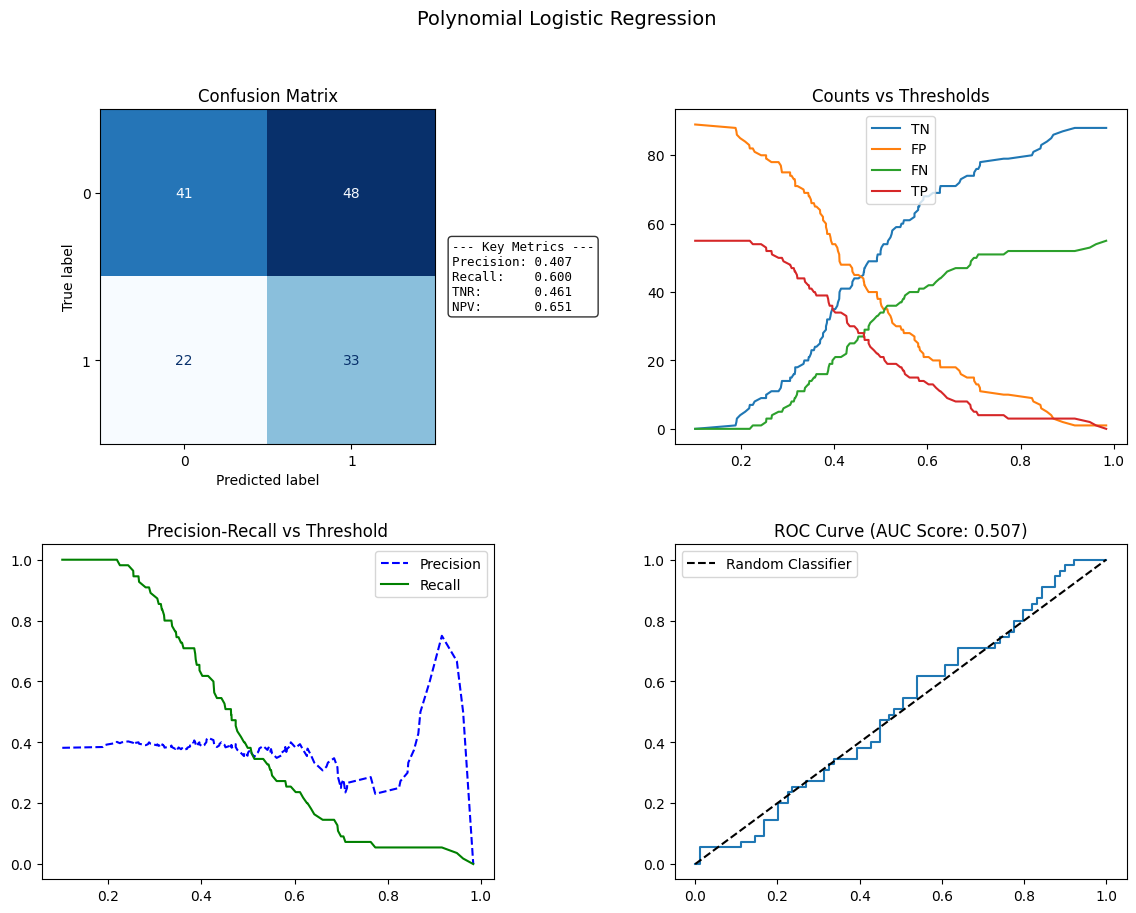

In [62]:
y_poly_test['pred'] = p4.reshape((-1, 1))
evaluate_classification_performance_2(y_poly_test, p4, f_wb4,
                                    confusion_matrix_at_thresholds,
                                    precision_recall_curve,
                                    roc_curve,
                                    roc_auc_score,
                                    'Polynomial Logistic Regression')

Confusion matrix manual implementation         - TN: 53, FP: 36, FN: 32, TP: 23, Total Count = 144


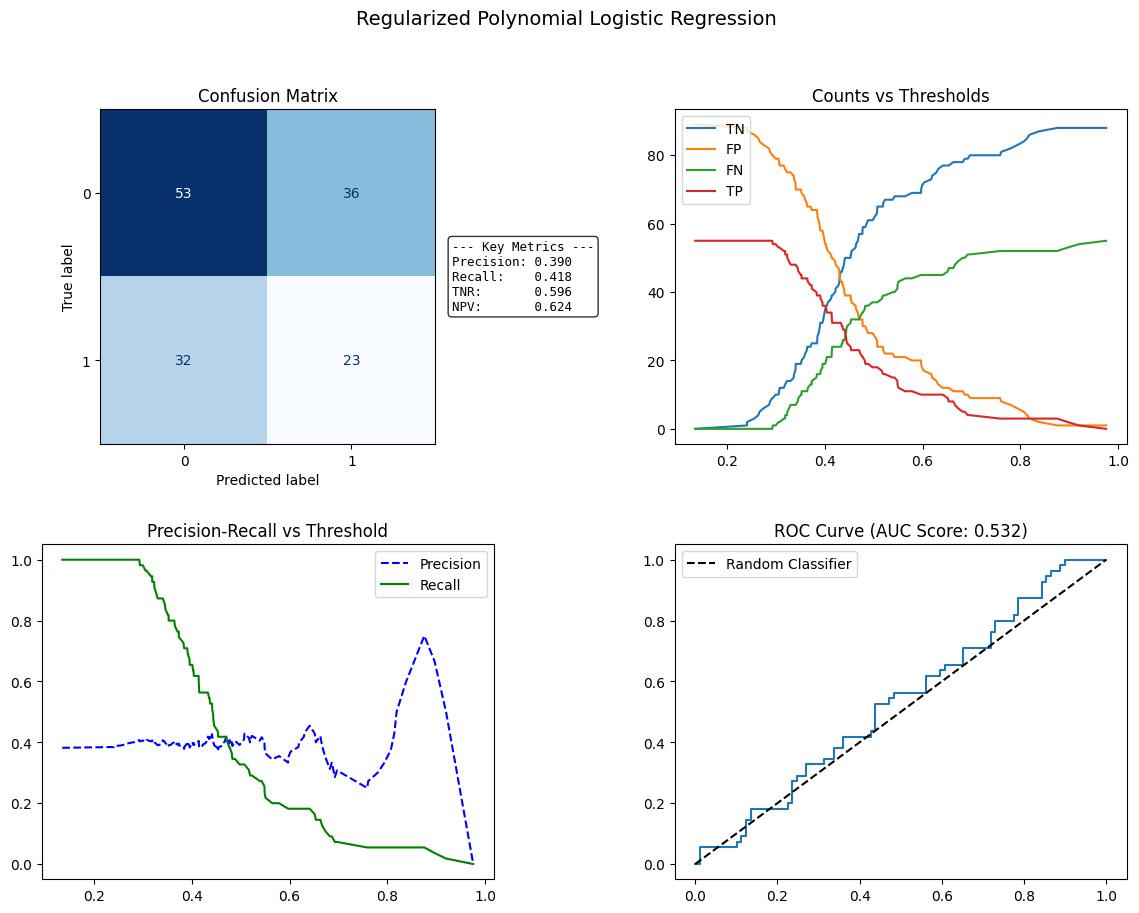

In [63]:
y_poly_test['pred'] = p6.reshape((-1, 1))
evaluate_classification_performance_2(y_poly_test, p6, f_wb6,
                                    confusion_matrix_at_thresholds,
                                    precision_recall_curve,
                                    roc_curve,
                                    roc_auc_score,
                                    'Regularized Polynomial Logistic Regression')

In [64]:
import pickle

# save the weights and bias of the regularized polynomial logistic regression model
model_manual = {
    'weights':w3,
    'bias':b3,
    'mu':X_poly_train_mu,
    'sigma':X_poly_train_sigma,
    'features_to_scale':cols_to_scale
}

with open('../model.pkl', 'wb') as f:
    pickle.dump(model_manual, f)